# 03 - K-Nearest Neighbors (KNN): Exact Search

---

In the previous notebook, we learned how to measure similarity between vectors.

Now we have another question.

Suppose we have 10,000 document embeddings.

How do we find the **K most similar documents**?

This problem is solved using **K-Nearest Neighbors (KNN)**.

In this notebook, we focus on **KNN as a search algorithm**, not as a classification algorithm.

##  History

Researchers converted documents into embeddings.

Great!

Now every document is a vector.

But users don't want similarity scores for every document.

Instead, they ask:

> Show me the **top 3** most similar documents.

Researchers solved this using **Nearest Neighbor Search**.

The simplest version is **Exact KNN Search**.

##  Think Like a Researcher

Imagine you have a library with 100 books.

A user asks:

"Books about AI."

Should you return all 100 books?

No.

You should return only the **most relevant** ones.

Exactly the same idea applies to vectors.

Instead of returning every vector,

we return the **K nearest vectors**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

documents = [
    "AI",
    "Machine Learning",
    "Deep Learning",
    "Football",
    "Cricket",
    "Basketball"
]

vectors = np.array([
    [1.0,1.1],
    [1.2,1.0],
    [0.9,0.8],
    [5.5,5.2],
    [5.8,5.0],
    [5.2,5.6]
])

query = np.array([1.1,1.0])

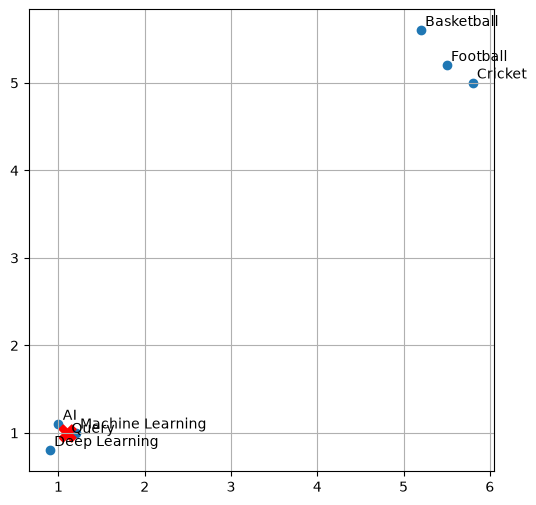

In [2]:
plt.figure(figsize=(6,6))

plt.scatter(vectors[:,0],vectors[:,1])

for label,point in zip(documents,vectors):
    plt.text(point[0]+0.05,point[1]+0.05,label)

plt.scatter(query[0],query[1],marker="X",s=150,color="red")

plt.text(query[0]+0.05,query[1],"Query")

plt.grid()

plt.show()

## Observation

Our query is close to

- AI
- Machine Learning
- Deep Learning

It is far from

- Football
- Cricket
- Basketball

Now let's calculate the exact distances.

In [3]:
def euclidean(a,b):
    return np.sqrt(np.sum((a-b)**2))

distances=[]

for label,vector in zip(documents,vectors):
    d=euclidean(query,vector)
    distances.append((label,d))

distances

[('AI', np.float64(0.14142135623730964)),
 ('Machine Learning', np.float64(0.09999999999999987)),
 ('Deep Learning', np.float64(0.28284271247461906)),
 ('Football', np.float64(6.082762530298219)),
 ('Cricket', np.float64(6.171709649683788)),
 ('Basketball', np.float64(6.161980201201558))]

In [4]:
sorted_distances = sorted(
    distances,
    key=lambda x:x[1]
)

sorted_distances

[('Machine Learning', np.float64(0.09999999999999987)),
 ('AI', np.float64(0.14142135623730964)),
 ('Deep Learning', np.float64(0.28284271247461906)),
 ('Football', np.float64(6.082762530298219)),
 ('Basketball', np.float64(6.161980201201558)),
 ('Cricket', np.float64(6.171709649683788))]

In [5]:
k=3

top_k=sorted_distances[:k]

top_k

[('Machine Learning', np.float64(0.09999999999999987)),
 ('AI', np.float64(0.14142135623730964)),
 ('Deep Learning', np.float64(0.28284271247461906))]

In [6]:
print(f"Top {k} nearest neighbors\n")

for doc,distance in top_k:
    print(doc,"->",round(distance,3))

Top 3 nearest neighbors

Machine Learning -> 0.1
AI -> 0.141
Deep Learning -> 0.283


In [7]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=3,
    metric="euclidean"
)

knn.fit(vectors)

distances,indices = knn.kneighbors([query])

indices

array([[1, 0, 2]])

In [8]:
for i,d in zip(indices[0],distances[0]):
    print(documents[i],round(d,3))

Machine Learning 0.1
AI 0.141
Deep Learning 0.283


## Choosing K

K = 1

↓

Return only the nearest vector.

K = 3

↓

Return the top three vectors.

K = 10

↓

Return the top ten vectors.

The value of **K** depends on the application.

## Why is this called Exact Search?

Notice what happened.

The query was compared with

every vector.

Nothing was skipped.

Therefore,

the answer is exact.

The nearest neighbor is guaranteed to be found.

## Time Complexity

Suppose

N = Number of vectors

For every query,

we compare against

all N vectors.

Time Complexity

O(N)

As N grows,

the search becomes slower.

In [9]:
sizes = [10,100,1000,10000,100000]

for n in sizes:
    print(
        f"{n} vectors -> {n} comparisons"
    )

10 vectors -> 10 comparisons
100 vectors -> 100 comparisons
1000 vectors -> 1000 comparisons
10000 vectors -> 10000 comparisons
100000 vectors -> 100000 comparisons


## Problem

Imagine:

100 million vectors.

Every query

↓

100 million comparisons.

Even if each comparison is very fast,

the total search becomes expensive.

Researchers asked:

Can we avoid checking every vector?

## Applications

Exact KNN is used for:

- Small Vector Databases
- Baseline evaluation
- Accuracy comparison
- Scientific datasets
- Testing ANN algorithms

## Advantages

✅ Simple

✅ Easy to understand

✅ Guaranteed nearest neighbors

✅ No approximation error

## Limitations

❌ Slow for large datasets

❌ Doesn't scale well

❌ Every vector must be checked

This limitation motivated Approximate Nearest Neighbor (ANN) algorithms.

##  Summary

Today I learned:

- What KNN means in vector search.
- How Exact Search works.
- How Top-K retrieval works.
- Why Exact Search guarantees correct results.
- Why Exact Search becomes slow as datasets grow.

##  Think Like a Researcher


We now know how to find the exact nearest neighbors.

But another question appears.

Suppose you have

1 billion vectors.

Should we still compare

the query

with every vector?

No.

Researchers realized that

a tiny loss in accuracy

could produce

huge gains in speed.

This idea became

**Approximate Nearest Neighbor (ANN).**